# CELL MESH Comprehensive Walkthrough with Fixed Test Data

This notebook documents the CELL MESH calculation flow using the packaged test files:

- `cellmesh/data/test_single_cell.h5ad`
- `cellmesh/data/Enzyme_new.csv`
- `cellmesh/data/Interaction1.0.csv`

It is a walkthrough, not the CI test suite. Automated boundary and regression tests live under `tests/`.

The walkthrough follows one metabolite by HMDB ID through prior validation, single-cell aggregation, P/C/E construction, bounded median contrasts, sensor scoring, and final communication event scoring.


## 1. Imports

Only current public APIs and stable module-level helpers are imported. The notebook avoids legacy scoring modules and old reaction-table conversion helpers.

In [26]:
from pathlib import Path
import os
import sys
import importlib
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

import cellmesh
import cellmesh.score as cellmesh_score
import cellmesh.core as cellmesh_core

# Editable installs do not refresh already-imported modules inside a running
# notebook kernel. Reload the scoring modules so this walkthrough uses the
# current working-tree implementation after code changes.
importlib.reload(cellmesh_score)
importlib.reload(cellmesh_core)
importlib.reload(cellmesh)

from cellmesh import (
    read_anndata,
    load_cell_mesh_database,
    compute_metabolite_availability,
    run_cell_mesh,
    bounded_median_contrast,
)
from cellmesh.database import validate_priors

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

print("python", sys.executable)
print("cellmesh", cellmesh.__version__)
print("cellmesh file", cellmesh.__file__)
print("has bounded_median_contrast", hasattr(cellmesh, "bounded_median_contrast"))


python /home/qsong/miniconda3/envs/cellmesh/bin/python
cellmesh 0.4.0
cellmesh file /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/__init__.py
has bounded_median_contrast True


## 2. Load Fixed Test Inputs

The notebook uses fixed package data so that examples and trace outputs remain stable across runs.

In [27]:
PACKAGE_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
DATA_DIR = PACKAGE_ROOT / "cellmesh" / "data"

h5ad_path = DATA_DIR / "test_single_cell.h5ad"
enzyme_path = DATA_DIR / "Enzyme_new.csv"
interaction_path = DATA_DIR / "Interaction1.0.csv"

adata = read_anndata(h5ad_path, mode="h5ad")
if "_index" in adata.var.columns:
    adata.var_names = adata.var["_index"].astype(str)

enzyme_metabolite, metabolite_sensor = load_cell_mesh_database(
    str(enzyme_path),
    str(interaction_path),
)

print("adata shape:", adata.shape)
print("enzyme prior rows:", len(enzyme_metabolite))
print("sensor prior rows:", len(metabolite_sensor))
adata.obs["cell_type"].astype(str).value_counts().rename("n_cells").to_frame()

adata shape: (500, 558)
enzyme prior rows: 40
sensor prior rows: 10252


,n_cells
cell_type,
Endothelial_cells,76
Epithelial_cells,72
T_cells,71
Macrophages,64
NK_cells,62
Dendritic_cells,58
Fibroblasts,51
B_cells,46


In [28]:
display(enzyme_metabolite.head())
display(metabolite_sensor.head())

,metabolite,hmdb_id,gene,role,weight,evidence_level,source,reaction
0,Uracil,HMDB0000300,PNP,production,1.0,Enzyme,packaged_enzyme_test,Deoxyuridine + Phosphate → Uracil + Deoxyribos...
1,Uracil,HMDB0000300,TYMP,production,1.0,Enzyme,packaged_enzyme_test,Deoxyuridine + Phosphate → Uracil + Deoxyribos...
2,Uracil,HMDB0000300,DPYD,production,1.0,Unknown,packaged_enzyme_test,Dihydrouracil + NADP → Uracil + NADPH
3,Uracil,HMDB0000300,DPYD,production,1.0,Unknown,packaged_enzyme_test,Dihydrouracil + NADP → Uracil + NADPH + Hydrog...
4,Uracil,HMDB0000300,UPP1,production,1.0,Enzyme,packaged_enzyme_test,Uridine + Phosphate → Uracil + Ribose 1-phosphate


,metabolite,hmdb_id,sensor_gene,sensor_type,weight,evidence_level,source,protein_name,reference
0,prostaglandin A1(1-),HMDB0002656,SLCO2A1,Transporter,1.0,Transporter,Recon2,SO2A1_HUMAN,NaN
1,Spermidine,HMDB0001257,SLC22A3,Transporter,1.0,Transporter,NaN,S22A3_HUMAN,10.1021/mp400024d
2,Spermine,HMDB0001256,SLC22A2,Transporter,1.0,Transporter,NaN,S22A1_HUMAN,10.1021/mp400024d
3,Spermidine,HMDB0001257,SLC22A2,Transporter,1.0,Transporter,NaN,S22A1_HUMAN,10.1021/mp400024d
4,Spermine,HMDB0001256,SLC22A1,Transporter,1.0,Transporter,"[MEBOCOST, MRCLinkdb]",S22A1_HUMAN,10.1074/jbc.271.51.32599


## 3. Validate Priors Against the Expression Matrix

`validate_priors()` is the runtime prior cleaning entry point used by `run_cell_mesh()`. It keeps rows with valid HMDB IDs, supported roles or sensor types, and genes present in `adata.var_names`.

In [29]:
enzyme_prior, sensor_prior = validate_priors(
    enzyme_metabolite,
    metabolite_sensor,
    adata.var_names,
)

matched_pairs = sorted(
    set(zip(enzyme_prior["metabolite"], enzyme_prior["hmdb_id"]))
    .intersection(zip(sensor_prior["metabolite"], sensor_prior["hmdb_id"]))
)

pd.DataFrame(
    {
        "table": ["enzyme_metabolite", "metabolite_sensor", "matched_metabolite_hmdb"],
        "raw_rows": [len(enzyme_metabolite), len(metabolite_sensor), np.nan],
        "validated_rows": [len(enzyme_prior), len(sensor_prior), len(matched_pairs)],
    }
)

,table,raw_rows,validated_rows
0,enzyme_metabolite,40.0,40
1,metabolite_sensor,10252.0,687
2,matched_metabolite_hmdb,NaN,5


In [30]:
match_summary = []
for metabolite, hmdb_id in matched_pairs:
    enz = enzyme_prior[(enzyme_prior["metabolite"] == metabolite) & (enzyme_prior["hmdb_id"] == hmdb_id)]
    sen = sensor_prior[(sensor_prior["metabolite"] == metabolite) & (sensor_prior["hmdb_id"] == hmdb_id)]
    match_summary.append(
        {
            "metabolite": metabolite,
            "hmdb_id": hmdb_id,
            "enzyme_rows": len(enz),
            "enzyme_genes": enz["gene"].nunique(),
            "roles": ", ".join(sorted(enz["role"].unique())),
            "sensor_rows": len(sen),
            "sensor_genes": sen["sensor_gene"].nunique(),
            "sensor_types": ", ".join(sorted(sen["sensor_type"].unique())),
        }
    )

pd.DataFrame(match_summary)

,metabolite,hmdb_id,enzyme_rows,enzyme_genes,roles,sensor_rows,sensor_genes,sensor_types
0,Adenosine triphosphate,HMDB0000538,6,6,"degradation, production",80,80,"Cell surface receptor, Other receptor, Transpo..."
1,L-Histidine,HMDB0000177,15,10,degradation,2,2,Transporter
2,Oleamide,HMDB0002117,2,2,degradation,1,1,Cell surface receptor
3,Uracil,HMDB0000300,7,6,production,1,1,Transporter
4,oxalate(2-),HMDB0002329,8,8,production,3,3,Transporter


In [31]:
enzyme_prior[(enzyme_prior["metabolite"] == 'Adenosine triphosphate') & (enzyme_prior["hmdb_id"] == 'HMDB0000538')]

,metabolite,hmdb_id,gene,role,weight,evidence_level,source,reaction
32,Adenosine triphosphate,HMDB0000538,SLC27A5,degradation,1.0,Enzyme,packaged_enzyme_test,"17alpha,20alpha-Dihydroxypregn-4-en-3-one + Ad..."
33,Adenosine triphosphate,HMDB0000538,HIBCH,production,1.0,Enzyme,packaged_enzyme_test,3-Hydroxypropionyl-CoA + Phosphate + ADP → Hyd...
34,Adenosine triphosphate,HMDB0000538,UCK1,degradation,1.0,Unknown,packaged_enzyme_test,5-Fluorouridine + Adenosine triphosphate → 5-F...
35,Adenosine triphosphate,HMDB0000538,UCK2,degradation,1.0,Unknown,packaged_enzyme_test,5-Fluorouridine + Adenosine triphosphate → 5-F...
36,Adenosine triphosphate,HMDB0000538,UCKL1,degradation,1.0,Enzyme,packaged_enzyme_test,5-Fluorouridine + Adenosine triphosphate → 5-F...
37,Adenosine triphosphate,HMDB0000538,ACLY,production,1.0,Enzyme,packaged_enzyme_test,ADP + Phosphate + Acetyl-CoA + Oxalacetic acid...


## 4. Run the Full CELL MESH Workflow

The test dataset has fewer than 100 cells per cell type, so this walkthrough explicitly uses `min_cells=1`. The software default remains `MIN_CELL_COUNT=100`.

In [32]:
res = run_cell_mesh(
    adata,
    enzyme_metabolite=enzyme_metabolite,
    metabolite_sensor=metabolite_sensor,
    cell_type_key="cell_type",
    min_cells=1,
    n_perms=0,
)

print("events:", res.events.shape)
print("sender_scores:", res.sender_scores.shape)
print("receiver_scores:", res.receiver_scores.shape)
display(res.events.head())

events: (5376, 15)
sender_scores: (4, 8)
receiver_scores: (5496, 8)


,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,metabolite_availability,sensor_score,sensor_expr_frac,sender_n_cells,receiver_n_cells,cell_mesh_score,perm_pvalue,fdr,confidence_tier
0,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,P2RX5,Cell surface receptor,0.062215,0.188053,0.827586,46,58,0.108165,NaN,NaN,Tier3_exploratory
1,B_cells,B_cells,Adenosine triphosphate,HMDB0000538,GUCY1B1,Other receptor,0.062215,0.162580,0.826087,46,46,0.100573,NaN,NaN,Tier3_exploratory
2,B_cells,Macrophages,Adenosine triphosphate,HMDB0000538,P2RY13,Cell surface receptor,0.062215,0.152415,0.718750,46,64,0.097378,NaN,NaN,Tier3_exploratory
3,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,SCNN1D,Transporter,0.062215,0.150276,0.793103,46,58,0.096692,NaN,NaN,Tier3_exploratory
4,B_cells,B_cells,Adenosine triphosphate,HMDB0000538,ACVRL1,Cell surface receptor,0.062215,0.148172,0.782609,46,46,0.096013,NaN,NaN,Tier3_exploratory


In [33]:
score_formula_ok = np.allclose(
    res.events["cell_mesh_score"],
    np.sqrt(res.events["metabolite_availability"] * res.events["sensor_score"]),
    atol=1e-12,
)
print("cell_mesh_score = sqrt(metabolite_availability * sensor_score):", score_formula_ok)
assert score_formula_ok

cell_mesh_score = sqrt(metabolite_availability * sensor_score): True


## 5. Select a Metabolite/HMDB Trace Target

The walkthrough tracks `Adenosine triphosphate / HMDB0000538` because it has both sender-side enzyme prior rows and receiver-side sensor rows after validation.

In [34]:
target_metabolite = "Adenosine triphosphate"
target_hmdb = "HMDB0000538"
target_key = (target_metabolite, target_hmdb)

target_enzyme = enzyme_prior[
    (enzyme_prior["metabolite"] == target_metabolite)
    & (enzyme_prior["hmdb_id"] == target_hmdb)
].copy()
target_sensor = sensor_prior[
    (sensor_prior["metabolite"] == target_metabolite)
    & (sensor_prior["hmdb_id"] == target_hmdb)
].copy()

assert not target_enzyme.empty
assert not target_sensor.empty

print("target enzyme rows:", len(target_enzyme))
print("target sensor rows:", len(target_sensor))
display(target_enzyme.groupby("role")["gene"].nunique().rename("n_genes").to_frame())
display(target_sensor.groupby("sensor_type")["sensor_gene"].nunique().rename("n_sensor_genes").to_frame())

target enzyme rows: 6
target sensor rows: 80


,n_genes
role,
degradation,4
production,2


,n_sensor_genes
sensor_type,
Cell surface receptor,42
Other receptor,22
Transporter,16


In [35]:
display(target_enzyme[["metabolite", "hmdb_id", "gene", "role", "reaction"]].head(20))
display(target_sensor[["metabolite", "hmdb_id", "sensor_gene", "sensor_type"]].head(20))

,metabolite,hmdb_id,gene,role,reaction
32,Adenosine triphosphate,HMDB0000538,SLC27A5,degradation,"17alpha,20alpha-Dihydroxypregn-4-en-3-one + Ad..."
33,Adenosine triphosphate,HMDB0000538,HIBCH,production,3-Hydroxypropionyl-CoA + Phosphate + ADP → Hyd...
34,Adenosine triphosphate,HMDB0000538,UCK1,degradation,5-Fluorouridine + Adenosine triphosphate → 5-F...
35,Adenosine triphosphate,HMDB0000538,UCK2,degradation,5-Fluorouridine + Adenosine triphosphate → 5-F...
36,Adenosine triphosphate,HMDB0000538,UCKL1,degradation,5-Fluorouridine + Adenosine triphosphate → 5-F...
37,Adenosine triphosphate,HMDB0000538,ACLY,production,ADP + Phosphate + Acetyl-CoA + Oxalacetic acid...


,metabolite,hmdb_id,sensor_gene,sensor_type
45,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor
55,Adenosine triphosphate,HMDB0000538,P2RY11,Cell surface receptor
56,Adenosine triphosphate,HMDB0000538,P2RY6,Cell surface receptor
58,Adenosine triphosphate,HMDB0000538,P2RY4,Cell surface receptor
61,Adenosine triphosphate,HMDB0000538,P2RY2,Cell surface receptor
62,Adenosine triphosphate,HMDB0000538,P2RY1,Cell surface receptor
64,Adenosine triphosphate,HMDB0000538,P2RX7,Cell surface receptor
65,Adenosine triphosphate,HMDB0000538,P2RX6,Other receptor
66,Adenosine triphosphate,HMDB0000538,P2RX5,Cell surface receptor
67,Adenosine triphosphate,HMDB0000538,P2RX4,Cell surface receptor


## 6. Metabolite Availability and Single-Cell Aggregation

`compute_metabolite_availability()` returns the pseudobulk matrix and expression fraction matrix used for both availability and sensor scoring. The pseudobulk aggregation is cell type by gene mean expression.

In [36]:
required_avail_keys = {
    "availability",
    "metadata",
    "P",
    "C",
    "E",
    "P_contrast",
    "C_contrast",
    "E_contrast",
    "P_plus",
    "relative_consumption_support",
    "E_plus",
}

avail = compute_metabolite_availability(
    adata,
    enzyme_prior,
    celltype_col="cell_type",
    min_cells=1,
    return_intermediates=True,
)

missing_avail_keys = sorted(required_avail_keys.difference(avail))
if missing_avail_keys:
    raise RuntimeError(
        "compute_metabolite_availability did not return the new median-contrast fields: "
        + ", ".join(missing_avail_keys)
        + ". Restart the notebook kernel and make sure it uses the local cellmesh package."
    )

assert target_key in avail["availability"].index
print(avail.keys())


dict_keys(['availability', 'metadata', 'P', 'C', 'E', 'P_contrast', 'C_contrast', 'E_contrast', 'P_plus', 'relative_consumption_support', 'E_plus', 'pseudobulk', 'expr_frac', 'cell_counts', 'reaction_genes'])


In [37]:
labels = adata.obs["cell_type"].astype(str)
X = adata.X
manual_rows = []
manual_index = []
for cell_type in avail["pseudobulk"].index:
    mask = labels.values == cell_type
    group_x = X[mask, :]
    mean = group_x.mean(axis=0)
    if hasattr(mean, "A1"):
        mean = mean.A1
    else:
        mean = np.asarray(mean).ravel()
    manual_rows.append(mean)
    manual_index.append(cell_type)

manual_pseudobulk = pd.DataFrame(
    np.vstack(manual_rows),
    index=manual_index,
    columns=pd.Index(adata.var_names).astype(str),
)

aggregation_ok = np.allclose(
    manual_pseudobulk.loc[avail["pseudobulk"].index, avail["pseudobulk"].columns],
    avail["pseudobulk"],
)
print("manual pseudobulk matches availability pseudobulk:", aggregation_ok)
assert aggregation_ok

manual pseudobulk matches availability pseudobulk: True


In [38]:
target_genes = sorted(set(target_enzyme["gene"]).intersection(avail["pseudobulk"].columns))
print("target enzyme genes in expression matrix:", len(target_genes))

role_by_gene = (
    target_enzyme.groupby("gene")["role"]
    .apply(lambda x: ", ".join(sorted(set(x))))
    .reindex(target_genes)
)

gene_expression_trace = avail["pseudobulk"][target_genes].T
gene_expression_trace.insert(0, "role", role_by_gene)
gene_expression_trace.head(30)

target enzyme genes in expression matrix: 6


,role,Endothelial_cells,Epithelial_cells,T_cells,Macrophages,NK_cells,Dendritic_cells,Fibroblasts,B_cells
_index,,,,,,,,,
ACLY,production,1.337975,1.047855,1.280904,1.290153,1.242582,1.062070,1.008188,1.310328
HIBCH,production,1.130348,1.306809,1.093164,0.989998,1.202406,1.466986,1.111757,1.418906
SLC27A5,degradation,1.139079,1.169885,1.150115,1.256416,1.107687,1.217782,1.117724,0.854478
UCK1,degradation,1.212361,1.228475,1.109121,0.927004,1.434697,1.394592,1.234712,1.353103
UCK2,degradation,1.184275,1.007089,1.139253,1.068982,1.019960,1.068247,1.401484,1.260716
UCKL1,degradation,1.069230,1.154595,1.041288,1.178710,1.229295,1.005519,1.112132,1.023018


In [39]:
gene_expr_frac_trace = avail["expr_frac"][target_genes].T
gene_expr_frac_trace.insert(0, "role", role_by_gene)
gene_expr_frac_trace.head(30)

,role,Endothelial_cells,Epithelial_cells,T_cells,Macrophages,NK_cells,Dendritic_cells,Fibroblasts,B_cells
_index,,,,,,,,,
ACLY,production,0.671053,0.527778,0.647887,0.640625,0.629032,0.568966,0.490196,0.586957
HIBCH,production,0.592105,0.638889,0.535211,0.515625,0.645161,0.706897,0.588235,0.673913
SLC27A5,degradation,0.552632,0.625000,0.605634,0.593750,0.580645,0.586207,0.607843,0.456522
UCK1,degradation,0.565789,0.638889,0.591549,0.484375,0.661290,0.689655,0.647059,0.673913
UCK2,degradation,0.605263,0.569444,0.591549,0.546875,0.516129,0.500000,0.705882,0.652174
UCKL1,degradation,0.565789,0.569444,0.563380,0.656250,0.596774,0.517241,0.568627,0.565217


## 7. P/C/E Raw Scores and Median Contrasts

Roles map internally to availability directions:

- `production` -> P / product
- `degradation` -> C / substrate
- `export` -> E / exporter

The tables below show the raw P/C/E proxies and their bounded contrasts relative to the equal-weight median across eligible cell types. Raw C represents the expression-derived level of metabolite-consuming enzyme complexes. Its positive median deviation is not a direct measurement of extracellular clearance flux.


In [40]:
required_avail_keys = {
    "availability",
    "P",
    "C",
    "E",
    "P_contrast",
    "C_contrast",
    "E_contrast",
    "P_plus",
    "relative_consumption_support",
    "E_plus",
}
missing_avail_keys = sorted(required_avail_keys.difference(avail))
if missing_avail_keys:
    print("Current in-memory avail is missing new fields; recomputing:", missing_avail_keys)
    avail = compute_metabolite_availability(
        adata,
        enzyme_prior,
        celltype_col="cell_type",
        min_cells=1,
        return_intermediates=True,
    )
    missing_avail_keys = sorted(required_avail_keys.difference(avail))
    if missing_avail_keys:
        raise RuntimeError(
            "compute_metabolite_availability still did not return the new median-contrast fields: "
            + ", ".join(missing_avail_keys)
            + ". Restart the notebook kernel and make sure it uses the local cellmesh package."
        )

pce_raw = pd.concat(
    {
        "P_raw": avail["P"].loc[target_key],
        "C_raw": avail["C"].loc[target_key],
        "E_raw": avail["E"].loc[target_key],
    },
    axis=1,
)
pce_contrast = pd.concat(
    {
        "P_contrast": avail["P_contrast"].loc[target_key],
        "C_contrast": avail["C_contrast"].loc[target_key],
        "E_contrast": avail["E_contrast"].loc[target_key],
        "P_plus": avail["P_plus"].loc[target_key],
        "relative_consumption_support": avail["relative_consumption_support"].loc[target_key],
        "E_plus": avail["E_plus"].loc[target_key],
        "sender_score": avail["availability"].loc[target_key],
    },
    axis=1,
)

display(pce_raw)
display(pce_contrast)


,P_raw,C_raw,E_raw
Endothelial_cells,2.468323,2.293467,0.0
Epithelial_cells,2.354664,2.297926,0.0
T_cells,2.374068,2.246267,0.0
Macrophages,2.280151,2.312052,0.0
NK_cells,2.444988,2.329215,0.0
Dendritic_cells,2.529056,2.367361,0.0
Fibroblasts,2.119945,2.364057,0.0
B_cells,2.729234,2.062291,0.0


,P_contrast,C_contrast,E_contrast,P_plus,relative_consumption_support,E_plus,sender_score
Endothelial_cells,0.012053,-0.002506,0.0,0.012053,0.000000,0.0,0.012053
Epithelial_cells,-0.011516,-0.001534,0.0,0.000000,0.000000,0.0,0.000000
T_cells,-0.007413,-0.012902,0.0,0.000000,0.000000,0.0,0.000000
Macrophages,-0.027588,0.001530,0.0,0.000000,0.001530,0.0,0.000000
NK_cells,0.007305,0.005228,0.0,0.007305,0.005228,0.0,0.007266
Dendritic_cells,0.024203,0.013349,0.0,0.024203,0.013349,0.0,0.023880
Fibroblasts,-0.063933,0.012651,0.0,0.000000,0.012651,0.0,0.000000
B_cells,0.062215,-0.055572,0.0,0.062215,0.000000,0.0,0.062215


In [41]:
p_plus = avail["P_plus"].loc[target_key]
c_plus = avail["relative_consumption_support"].loc[target_key]
e_plus = avail["E_plus"].loc[target_key]
metadata = avail["metadata"].loc[target_key]

exporter_factor = 1 + e_plus if metadata["has_exporter"] else 1.0
consumption_factor = 1 - c_plus if metadata["has_substrate"] else 1.0
manual_sender_score = p_plus * exporter_factor * consumption_factor

availability_check = pd.DataFrame(
    {
        "manual_sender_score": manual_sender_score,
        "reported_sender_score": avail["availability"].loc[target_key],
    }
)
availability_check["abs_diff"] = (
    availability_check["manual_sender_score"] - availability_check["reported_sender_score"]
).abs()
display(availability_check)
assert np.allclose(
    availability_check["manual_sender_score"],
    availability_check["reported_sender_score"],
    atol=1e-12,
)


,manual_sender_score,reported_sender_score,abs_diff
Endothelial_cells,0.012053,0.012053,0.0
Epithelial_cells,0.000000,0.000000,0.0
T_cells,0.000000,0.000000,0.0
Macrophages,0.000000,0.000000,0.0
NK_cells,0.007266,0.007266,0.0
Dendritic_cells,0.023880,0.023880,0.0
Fibroblasts,0.000000,0.000000,0.0
B_cells,0.062215,0.062215,0.0


In [42]:
target_reactions = avail["reaction_genes"][
    (avail["reaction_genes"]["metabolite"] == target_metabolite)
    & (avail["reaction_genes"]["hmdb_id"] == target_hmdb)
].copy()

target_reactions["n_genes"] = target_reactions["genes"].apply(len)
target_reactions[["metabolite", "hmdb_id", "reaction", "direction", "n_genes", "genes"]].head(30)

,metabolite,hmdb_id,reaction,direction,n_genes,genes
17,Adenosine triphosphate,HMDB0000538,"17alpha,20alpha-Dihydroxypregn-4-en-3-one + Ad...",substrate,1,[SLC27A5]
18,Adenosine triphosphate,HMDB0000538,3-Hydroxypropionyl-CoA + Phosphate + ADP → Hyd...,product,1,[HIBCH]
19,Adenosine triphosphate,HMDB0000538,5-Fluorouridine + Adenosine triphosphate → 5-F...,substrate,3,"[UCK1, UCK2, UCKL1]"
20,Adenosine triphosphate,HMDB0000538,ADP + Phosphate + Acetyl-CoA + Oxalacetic acid...,product,1,[ACLY]


## 8. Receiver Sensor Score Trace

For the same HMDB ID, receiver-side scores are the positive bounded median contrasts of sensor-gene pseudobulk expression across eligible cell types. `min_expr_frac` is an optional receiver-only gate and defaults to `None`.


In [43]:
target_receiver_scores = res.receiver_scores[res.receiver_scores["hmdb_id"] == target_hmdb].copy()
assert not target_receiver_scores.empty

display(target_receiver_scores.head(20))

,metabolite,hmdb_id,sensor_gene,sensor_type,receiver,sensor_score,sensor_expr_frac,receiver_n_cells
360,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,Endothelial_cells,0.090279,0.644737,76
361,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,Epithelial_cells,0.000000,0.583333,72
362,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,T_cells,0.000000,0.563380,71
363,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,Macrophages,0.004280,0.515625,64
364,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,NK_cells,0.071701,0.596774,62
365,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,Dendritic_cells,0.000000,0.465517,58
366,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,Fibroblasts,0.042563,0.529412,51
367,Adenosine triphosphate,HMDB0000538,P2RX1,Cell surface receptor,B_cells,0.000000,0.521739,46
440,Adenosine triphosphate,HMDB0000538,P2RY11,Cell surface receptor,Endothelial_cells,0.000000,0.513158,76
441,Adenosine triphosphate,HMDB0000538,P2RY11,Cell surface receptor,Epithelial_cells,0.000000,0.541667,72


In [44]:
example_sensor_gene = target_receiver_scores.iloc[0]["sensor_gene"]
manual_sensor_score = pd.Series(
    np.maximum(
        0.0,
        bounded_median_contrast(avail["pseudobulk"][example_sensor_gene].values),
    ),
    index=avail["pseudobulk"].index,
    name="manual_sensor_score",
)
reported_sensor = target_receiver_scores[
    target_receiver_scores["sensor_gene"] == example_sensor_gene
].set_index("receiver")

sensor_trace = pd.concat(
    [
        avail["pseudobulk"][example_sensor_gene].rename("pseudobulk_expr"),
        avail["expr_frac"][example_sensor_gene].rename("expr_frac"),
        manual_sensor_score,
        reported_sensor["sensor_score"].rename("reported_sensor_score"),
    ],
    axis=1,
)

display(sensor_trace)
assert np.allclose(
    sensor_trace["manual_sensor_score"],
    sensor_trace["reported_sensor_score"],
    atol=1e-12,
)


,pseudobulk_expr,expr_frac,manual_sensor_score,reported_sensor_score
Endothelial_cells,1.267418,0.644737,0.090279,0.090279
Epithelial_cells,1.048434,0.583333,0.000000,0.000000
T_cells,1.013506,0.563380,0.000000,0.000000
Macrophages,1.066616,0.515625,0.004280,0.004280
NK_cells,1.220891,0.596774,0.071701,0.071701
Dendritic_cells,0.909729,0.465517,0.000000,0.000000
Fibroblasts,1.151551,0.529412,0.042563,0.042563
B_cells,0.953152,0.521739,0.000000,0.000000


## 9. Final Event Trace for the Target HMDB ID

Events are matched on both metabolite name and `hmdb_id`. Rows without valid HMDB IDs are excluded before event construction.

In [45]:
target_events = res.events[res.events["hmdb_id"] == target_hmdb].copy()
assert not target_events.empty

display(
    target_events[
        [
            "sender",
            "receiver",
            "metabolite",
            "hmdb_id",
            "sensor_gene",
            "sensor_type",
            "metabolite_availability",
            "sensor_score",
            "cell_mesh_score",
        ]
    ].head(20)
)

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,metabolite_availability,sensor_score,cell_mesh_score
0,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,P2RX5,Cell surface receptor,0.062215,0.188053,0.108165
1,B_cells,B_cells,Adenosine triphosphate,HMDB0000538,GUCY1B1,Other receptor,0.062215,0.162580,0.100573
2,B_cells,Macrophages,Adenosine triphosphate,HMDB0000538,P2RY13,Cell surface receptor,0.062215,0.152415,0.097378
3,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,SCNN1D,Transporter,0.062215,0.150276,0.096692
4,B_cells,B_cells,Adenosine triphosphate,HMDB0000538,ACVRL1,Cell surface receptor,0.062215,0.148172,0.096013
5,B_cells,NK_cells,Adenosine triphosphate,HMDB0000538,NPR2,Cell surface receptor,0.062215,0.129906,0.089900
6,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,P2RY11,Cell surface receptor,0.062215,0.128039,0.089252
7,B_cells,Endothelial_cells,Adenosine triphosphate,HMDB0000538,MET,Cell surface receptor,0.062215,0.125910,0.088507
8,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,CFTR,Transporter,0.062215,0.125376,0.088319
9,B_cells,Epithelial_cells,Adenosine triphosphate,HMDB0000538,LPAR6,Cell surface receptor,0.062215,0.123258,0.087570


In [46]:
target_events

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,metabolite_availability,sensor_score,sensor_expr_frac,sender_n_cells,receiver_n_cells,cell_mesh_score,perm_pvalue,fdr,confidence_tier
0,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,P2RX5,Cell surface receptor,0.062215,0.188053,0.827586,46,58,0.108165,NaN,NaN,Tier3_exploratory
1,B_cells,B_cells,Adenosine triphosphate,HMDB0000538,GUCY1B1,Other receptor,0.062215,0.162580,0.826087,46,46,0.100573,NaN,NaN,Tier3_exploratory
2,B_cells,Macrophages,Adenosine triphosphate,HMDB0000538,P2RY13,Cell surface receptor,0.062215,0.152415,0.718750,46,64,0.097378,NaN,NaN,Tier3_exploratory
3,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,SCNN1D,Transporter,0.062215,0.150276,0.793103,46,58,0.096692,NaN,NaN,Tier3_exploratory
4,B_cells,B_cells,Adenosine triphosphate,HMDB0000538,ACVRL1,Cell surface receptor,0.062215,0.148172,0.782609,46,46,0.096013,NaN,NaN,Tier3_exploratory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,Fibroblasts,B_cells,Adenosine triphosphate,HMDB0000538,TLR7,Other receptor,0.000000,0.000000,0.521739,51,46,0.000000,NaN,NaN,Tier3_exploratory
5372,Endothelial_cells,NK_cells,Adenosine triphosphate,HMDB0000538,P2RY1,Cell surface receptor,0.012053,0.000000,0.580645,76,62,0.000000,NaN,NaN,Tier3_exploratory
5373,Fibroblasts,Macrophages,Adenosine triphosphate,HMDB0000538,TLR7,Other receptor,0.000000,0.024079,0.656250,51,64,0.000000,NaN,NaN,Tier3_exploratory
5374,Macrophages,Macrophages,Adenosine triphosphate,HMDB0000538,TLR7,Other receptor,0.000000,0.024079,0.656250,64,64,0.000000,NaN,NaN,Tier3_exploratory


In [47]:
event = target_events.iloc[0]
manual_event_score = np.sqrt(event["metabolite_availability"] * event["sensor_score"])
print("manual event score:", manual_event_score)
print("reported event score:", event["cell_mesh_score"])
assert np.isclose(manual_event_score, event["cell_mesh_score"])

manual event score: 0.10816487342138097
reported event score: 0.10816487342138097


## 10. Optional Permutation Smoke Check

This small run only verifies that permutation columns are produced. It is not intended as a statistically powered permutation analysis.

In [48]:
res_perm = run_cell_mesh(
    adata,
    enzyme_metabolite=enzyme_metabolite,
    metabolite_sensor=metabolite_sensor,
    cell_type_key="cell_type",
    min_cells=1,
    n_perms=10,
    random_state=0,
)

res_perm.events[["metabolite", "hmdb_id", "sensor_type", "perm_pvalue", "fdr", "confidence_tier"]].head()

,metabolite,hmdb_id,sensor_type,perm_pvalue,fdr,confidence_tier
0,Adenosine triphosphate,HMDB0000538,Cell surface receptor,0.090909,0.92562,Tier3_exploratory
1,Adenosine triphosphate,HMDB0000538,Cell surface receptor,0.090909,0.92562,Tier3_exploratory
2,Adenosine triphosphate,HMDB0000538,Cell surface receptor,0.090909,0.92562,Tier3_exploratory
3,Adenosine triphosphate,HMDB0000538,Cell surface receptor,0.090909,0.92562,Tier3_exploratory
4,Adenosine triphosphate,HMDB0000538,Cell surface receptor,0.090909,0.92562,Tier3_exploratory


In [49]:
res_perm.events

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,metabolite_availability,sensor_score,sensor_expr_frac,sender_n_cells,receiver_n_cells,cell_mesh_score,perm_pvalue,fdr,confidence_tier
0,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,P2RX5,Cell surface receptor,0.062215,0.188053,0.827586,46,58,0.108165,0.090909,0.92562,Tier3_exploratory
1,B_cells,Macrophages,Adenosine triphosphate,HMDB0000538,P2RY13,Cell surface receptor,0.062215,0.152415,0.718750,46,64,0.097378,0.090909,0.92562,Tier3_exploratory
2,B_cells,B_cells,Adenosine triphosphate,HMDB0000538,ACVRL1,Cell surface receptor,0.062215,0.148172,0.782609,46,46,0.096013,0.090909,0.92562,Tier3_exploratory
3,B_cells,NK_cells,Adenosine triphosphate,HMDB0000538,NPR2,Cell surface receptor,0.062215,0.129906,0.725806,46,62,0.089900,0.090909,0.92562,Tier3_exploratory
4,B_cells,Dendritic_cells,Adenosine triphosphate,HMDB0000538,P2RY11,Cell surface receptor,0.062215,0.128039,0.741379,46,58,0.089252,0.090909,0.92562,Tier3_exploratory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,Fibroblasts,B_cells,Adenosine triphosphate,HMDB0000538,TLR7,Other receptor,0.000000,0.000000,0.521739,51,46,0.000000,1.000000,1.00000,Tier3_exploratory
5372,Endothelial_cells,NK_cells,Adenosine triphosphate,HMDB0000538,P2RY1,Cell surface receptor,0.012053,0.000000,0.580645,76,62,0.000000,1.000000,1.00000,Tier3_exploratory
5373,Fibroblasts,Macrophages,Adenosine triphosphate,HMDB0000538,TLR7,Other receptor,0.000000,0.024079,0.656250,51,64,0.000000,1.000000,1.00000,Tier3_exploratory
5374,Macrophages,Macrophages,Adenosine triphosphate,HMDB0000538,TLR7,Other receptor,0.000000,0.024079,0.656250,64,64,0.000000,1.000000,1.00000,Tier3_exploratory


## 11. Sender-Receiver Heatmap for One Metabolite

For the tracked metabolite/HMDB pair, this heatmap summarizes one selected event per sender-receiver pair. The selected event is the lowest-FDR event for that pair, with `cell_mesh_score` used as the tie-breaker. Color represents FDR and the cell annotation shows `cell_mesh_score`.


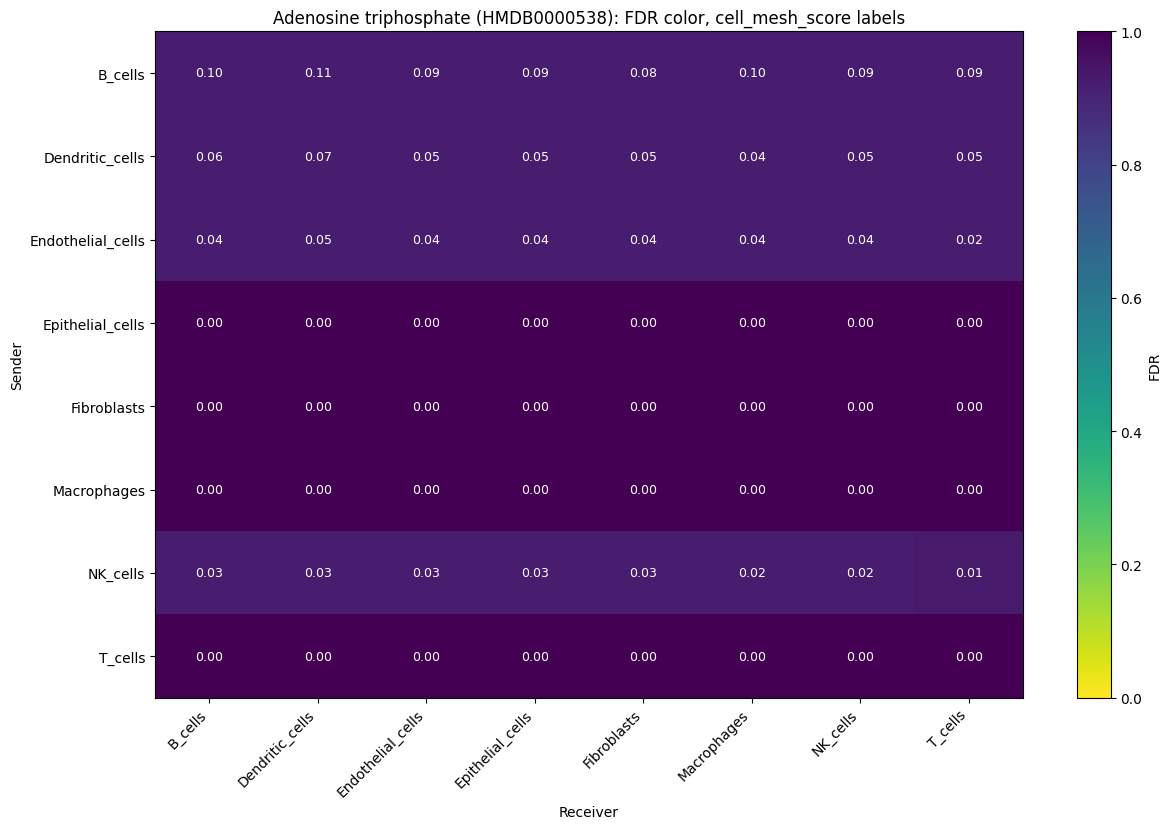

,sender,receiver,sensor_gene,sensor_type,fdr,cell_mesh_score
2,B_cells,B_cells,ACVRL1,Cell surface receptor,0.92562,0.096013
0,B_cells,Dendritic_cells,P2RX5,Cell surface receptor,0.92562,0.108165
5,B_cells,Endothelial_cells,MET,Cell surface receptor,0.92562,0.088507
6,B_cells,Epithelial_cells,LPAR6,Cell surface receptor,0.92562,0.087570
12,B_cells,Fibroblasts,P2RY12,Cell surface receptor,0.92562,0.079860
1,B_cells,Macrophages,P2RY13,Cell surface receptor,0.92562,0.097378
3,B_cells,NK_cells,NPR2,Cell surface receptor,0.92562,0.089900
7,B_cells,T_cells,P2RY13,Cell surface receptor,0.92562,0.086197
40,Dendritic_cells,B_cells,ACVRL1,Cell surface receptor,0.92562,0.059484
32,Dendritic_cells,Dendritic_cells,P2RX5,Cell surface receptor,0.92562,0.067012


In [50]:
heatmap_events = res_perm.events[
    (res_perm.events["metabolite"] == target_metabolite)
    & (res_perm.events["hmdb_id"] == target_hmdb)
].copy()

assert not heatmap_events.empty

# Multiple sensor genes can exist for the same sender-receiver pair. For a
# compact sender x receiver view, select the event with the lowest FDR; if tied,
# keep the higher cell_mesh_score.
heatmap_best = (
    heatmap_events
    .sort_values(["sender", "receiver", "fdr", "cell_mesh_score"], ascending=[True, True, True, False], na_position="last")
    .drop_duplicates(subset=["sender", "receiver"], keep="first")
)

fdr_matrix = heatmap_best.pivot(index="sender", columns="receiver", values="fdr")
score_matrix = heatmap_best.pivot(index="sender", columns="receiver", values="cell_mesh_score")

fig, ax = plt.subplots(figsize=(1.2 * len(fdr_matrix.columns) + 3, 0.8 * len(fdr_matrix.index) + 2))
image = ax.imshow(fdr_matrix.to_numpy(dtype=float), cmap="viridis_r", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(np.arange(len(fdr_matrix.columns)))
ax.set_xticklabels(fdr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(fdr_matrix.index)))
ax.set_yticklabels(fdr_matrix.index)
ax.set_xlabel("Receiver")
ax.set_ylabel("Sender")
ax.set_title(f"{target_metabolite} ({target_hmdb}): FDR color, cell_mesh_score labels")

for i, sender in enumerate(fdr_matrix.index):
    for j, receiver in enumerate(fdr_matrix.columns):
        score = score_matrix.loc[sender, receiver]
        if pd.notna(score):
            ax.text(j, i, f"{score:.2f}", ha="center", va="center", color="white", fontsize=9)

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("FDR")
fig.tight_layout()
plt.show()

heatmap_best[["sender", "receiver", "sensor_gene", "sensor_type", "fdr", "cell_mesh_score"]].head(20)


## 12. Notes for Maintenance
